In [5]:
from sklearn.datasets import load_iris

iris = load_iris()
x, y = iris.data, iris.target

print(iris.feature_names)
print(iris.target_names)

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
['setosa' 'versicolor' 'virginica']


## Data preprocessing

In [ ]:
iris.describe()

## Data Splitting

In [34]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=1)


In [35]:
x_train[:10]

array([[6.1, 3. , 4.6, 1.4],
       [7.7, 3. , 6.1, 2.3],
       [5.6, 2.5, 3.9, 1.1],
       [6.4, 2.8, 5.6, 2.1],
       [5.8, 2.8, 5.1, 2.4],
       [5.3, 3.7, 1.5, 0.2],
       [5.5, 2.3, 4. , 1.3],
       [5.2, 3.4, 1.4, 0.2],
       [6.5, 2.8, 4.6, 1.5],
       [6.7, 2.5, 5.8, 1.8]])

In [36]:
y_train[:10]

array([1, 2, 1, 2, 2, 0, 1, 0, 1, 2])

In [37]:
for i, value in enumerate(iris.target_names):
    print(i, value)

0 setosa
1 versicolor
2 virginica


In [38]:
len(x_train), len(x_test), len(y_train), len(y_test)

(120, 30, 120, 30)

## Model Selection and Training

In [48]:
from sklearn.ensemble import RandomForestClassifier

iris_model = RandomForestClassifier(random_state=42, n_estimators=150, max_depth=5)

iris_model.fit(x_train, y_train)

,n_estimators,150
,criterion,'gini'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [53]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

predictions = iris_model.predict(x_test)

accuracy = accuracy_score(predictions, y_test)

print('Random Forest Accuracy:', accuracy * 100)

Random Forest Accuracy: 96.66666666666667


In [43]:
print(classification_report(predictions, y_test))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       0.92      1.00      0.96        12
           2       1.00      0.86      0.92         7

    accuracy                           0.97        30
   macro avg       0.97      0.95      0.96        30
weighted avg       0.97      0.97      0.97        30



## Logistic Regression

In [46]:
from sklearn.linear_model import LogisticRegression

iris_log = LogisticRegression(max_iter=200)

iris_log.fit(x_train, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,200
,multi_class,'deprecated'


In [47]:
iris_pred = iris_model.predict(x_test)

accuracy = accuracy_score(iris_pred, y_test)

print('Iris Logistic Regression Accuracy', accuracy * 100)

Iris Logistic Regression Accuracy 96.66666666666667


In [51]:
print("\nConfusion Matrix:\n", confusion_matrix(y_test, iris_pred))


Confusion Matrix:
 [[11  0  0]
 [ 0 12  1]
 [ 0  0  6]]


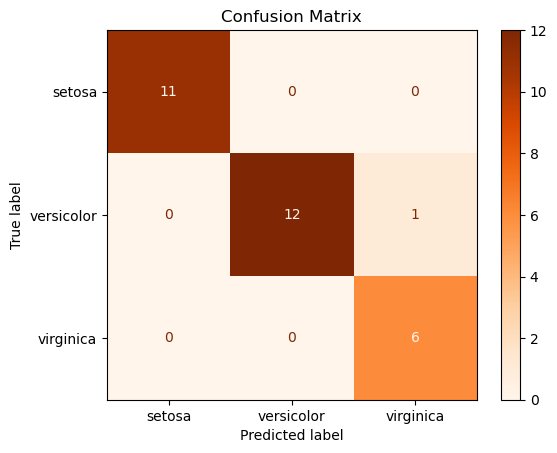

In [54]:
import matplotlib.pyplot as plt

cm_display = ConfusionMatrixDisplay(confusion_matrix(y_test, iris_pred), display_labels=iris.target_names)

cm_display.plot(cmap=plt.cm.Oranges)

plt.title('Confusion Matrix')
# plt.colorbar()
plt.show()

## Creating a Prediction Function

In [62]:
def predict_flower(sepal_length, sepal_width, petal_length, petal_width):

    sample = [[sepal_length, sepal_width, petal_length, petal_width]]

    pred = iris_model.predict(sample)[0]

    species = iris.target_names
    prediction = f'The specie of flower is {species[pred]}'

    return prediction

In [63]:
predict_flower(5.1, 3.5, 1.4, 0.2)

'The specie of flower is setosa'

In [67]:
predict_flower(6.0, 3.0, 4.8, 1.8)

'The specie of flower is virginica'

In [69]:
predict_flower(8.1, 2.9, 4.2, 1.1)

'The specie of flower is versicolor'